In [81]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils.np_utils import to_categorical
import random

In [82]:
np.random.seed(0)

In [83]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

#60k training mnist images with labels, 10k test mnist images with labels

In [84]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape[0])

(60000, 28, 28)
(10000, 28, 28)
60000


In [85]:
assert(X_train.shape[0] == y_train.shape[0]), "The number of images is not equal to the number of labels."
assert(X_test.shape[0] == y_test.shape[0]), "The number of images is not equal to the number of labels."
assert(X_train.shape[1:] == (28,28)), "The dimensions of the images are not 28x28"
assert(X_test.shape[1:] == (28,28)), "The dimensions of the images are not 28x28"

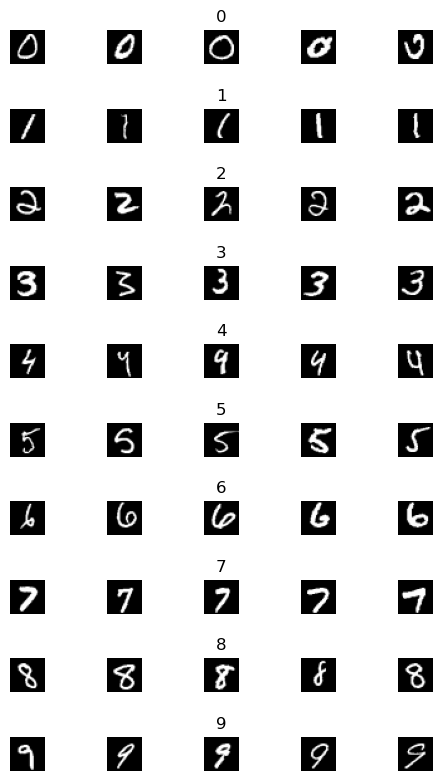

In [86]:
num_of_samples = []
cols = 5
num_classes = 10
 
fig, axs = plt.subplots(nrows=num_classes, ncols = cols, figsize=(5, 8))
            #Multiple plotes on same figure
fig.tight_layout()      #Minizes overlapping between plots. Provides a gap.
for i in range(cols):
    for j in range(num_classes):
        x_selected = X_train[y_train == j]
        axs[j][i].imshow(x_selected[random.randint(0, len(x_selected - 1)), :, :], cmap=plt.get_cmap("gray"))
        axs[j][i].axis("off")
        if i == 2:
            axs[j][i].set_title(str(j))
            num_of_samples.append(len(x_selected))

[5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]


Text(0, 0.5, 'Number of images')

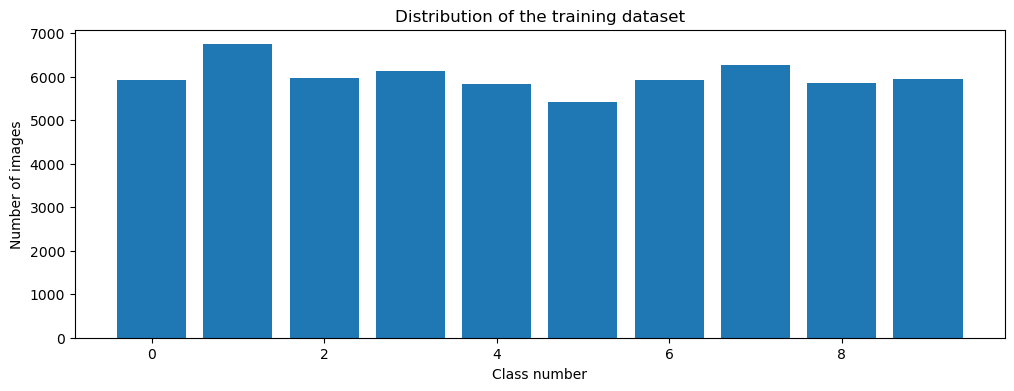

In [87]:
print(num_of_samples)
plt.figure(figsize=(12, 4))
plt.bar(range(0, num_classes), num_of_samples)
plt.title("Distribution of the training dataset")
plt.xlabel("Class number")
plt.ylabel("Number of images")

In [88]:
y_train = to_categorical(y_train, 10)           #OHE
y_test = to_categorical(y_test, 10)

In [89]:
X_train = X_train/255                            
X_test = X_test/255
"""Normalising pixel values 0 - 255 to 0 - 1. Scales down oue features to a uniform range. 
Decreases Variance amoung our data. Helps NN to learn more quickly and accurately"""

'Normalising pixel values 0 - 255 to 0 - 1. Scales down oue features to a uniform range. \nDecreases Variance amoung our data. Helps NN to learn more quickly and accurately'

In [90]:
num_pixels = 784
X_train = X_train.reshape(X_train.shape[0], num_pixels)
#(60000, 28, 28)    -->     (60000, 784)
X_test = X_test.reshape(X_test.shape[0], num_pixels)
#(60000, 28, 28)    -->     (60000, 784)

"""Instead of 28x28 pixels (2 dim), we need to flatten it to single row with 784 pixels"""

'Instead of 28x28 pixels (2 dim), we need to flatten it to single row with 784 pixels'

In [91]:
print(X_train.shape)

(60000, 784)


In [92]:
def create_model():
    model = Sequential()
    model.add(Dense(10, input_dim=num_pixels, activation='relu'))
    model.add(Dense(30, activation='relu'))
    model.add(Dense(10, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(Adam(lr=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [93]:
model = create_model()
print(model.summary())

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_12 (Dense)             (None, 10)                7850      
_________________________________________________________________
dense_13 (Dense)             (None, 30)                330       
_________________________________________________________________
dense_14 (Dense)             (None, 10)                310       
_________________________________________________________________
dense_15 (Dense)             (None, 10)                110       
Total params: 8,600
Trainable params: 8,600
Non-trainable params: 0
_________________________________________________________________
None


In [94]:
history = model.fit(X_train, y_train, validation_split=0.1, epochs = 10, batch_size = 200, verbose = 1, shuffle = 1)

Epoch 1/10
270/270 [==============================] - 1s 3ms/step - loss: 0.5143 - accuracy: 0.8420 - val_loss: 0.2460 - val_accuracy: 0.9290
Epoch 2/10
270/270 [==============================] - 1s 3ms/step - loss: 0.2792 - accuracy: 0.9185 - val_loss: 0.2015 - val_accuracy: 0.9425
Epoch 3/10
270/270 [==============================] - 1s 3ms/step - loss: 0.2434 - accuracy: 0.9283 - val_loss: 0.2063 - val_accuracy: 0.9410
Epoch 4/10
270/270 [==============================] - 1s 3ms/step - loss: 0.2273 - accuracy: 0.9330 - val_loss: 0.1786 - val_accuracy: 0.9493
Epoch 5/10
270/270 [==============================] - 1s 3ms/step - loss: 0.2173 - accuracy: 0.9358 - val_loss: 0.1845 - val_accuracy: 0.9460
Epoch 6/10
270/270 [==============================] - 1s 3ms/step - loss: 0.2033 - accuracy: 0.9405 - val_loss: 0.1676 - val_accuracy: 0.9503
Epoch 7/10
270/270 [==============================] - 1s 3ms/step - loss: 0.1920 - accuracy: 0.9432 - val_loss: 0.1620 - val_accuracy: 0.9513
Epoch 

Text(0.5, 0, 'epoch')

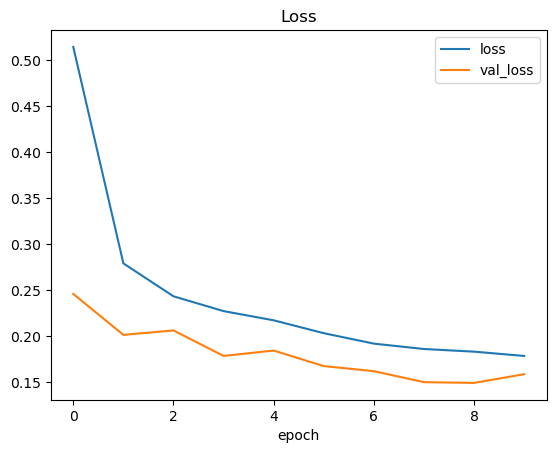

In [95]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.title('Loss')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

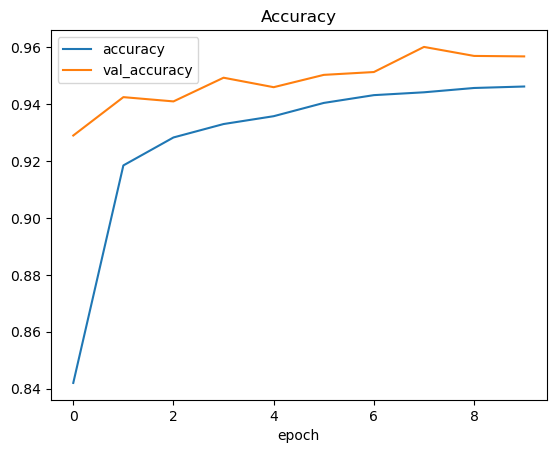

In [96]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.title('Accuracy')
plt.xlabel('epoch')

In [97]:
score = model.evaluate(X_test, y_test, verbose=0)
print(type(score))
print('Test score:', score[0])
print('Test accuracy:', score[1])

<class 'list'>
Test score: 0.205527201294899
Test accuracy: 0.9423999786376953


Download the Image

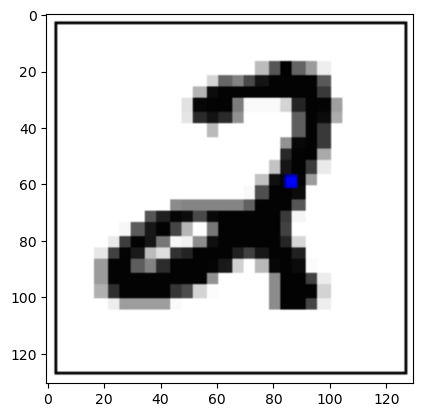

In [98]:
import requests
from PIL import Image

url = 'https://colah.github.io/posts/2014-10-Visualizing-MNIST/img/mnist_pca/MNIST-p1815-4.png'
response = requests.get(url, stream=True)
img = Image.open(response.raw)
plt.imshow(img, cmap='gray')

Preprocess the Image

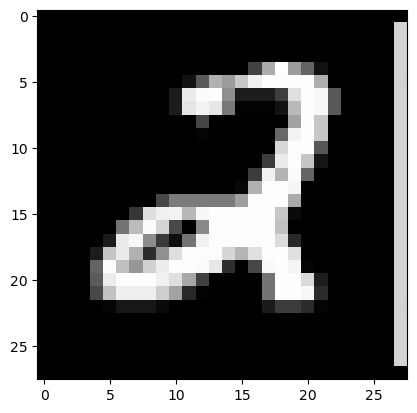

In [99]:
import cv2
 
img = np.asarray(img)
img = cv2.resize(img, (28, 28))
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.bitwise_not(img)
plt.imshow(img, cmap=plt.get_cmap('gray'))

In [100]:
img = img/255
img = img.reshape(1, 784)

In [102]:
prediction = model.predict_classes(img)
print("predicted digit:", str(prediction))

predicted digit: [2]
